# Machine Learning Systems for Sleep Quality Assessment Based on EEG Signals

---

* **Author**: Carmen-Theodora Craciun
* **Previos step**:
  * all ETL steps from folder `/datasets_ETL`
  * Feature extraction step
**Machine Learning paradigm:** Supervised learning
* **Datasets**:
  * [Sleep-EDFX Database](https://www.physionet.org/content/sleep-edfx/1.0.0/) - channel EEG Fpz-Cz
  * [University College Dublin Sleep Apnea Database](https://physionet.org/content/ucddb/1.0.0/) - channel EEG C3-A2
  * [Haaglanden Medisch Centrum sleep staging database (PhysioNet)](https://physionet.org/content/hmc-sleep-staging/1.1/recordings/#files-panel) - channel EEG C4-M1
* **Models**: Machine Learning - Decision Tree based models

# Imports

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import numpy as np
import pandas as pd
from sklearn.utils.class_weight import compute_sample_weight
import sys
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
from sklearn.calibration import CalibratedClassifierCV

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/sleep_data'
helper_functions_path = base_path + '/helper_functions'

Mounted at /content/drive


In [5]:
sys.path.append(helper_functions_path)

import utils as utils

# Datasets

In [6]:
df_train = pd.read_csv(base_path + '/process_dataset/extracted_features/train_features.csv')
df_val = pd.read_csv(base_path + '/process_dataset/extracted_features/val_features.csv')

In [ ]:
cols_to_drop = ['Subject_ID', 'Dataset_Source', 'Label']
feature_cols = [c for c in df_train.columns if c not in cols_to_drop]

X_train = df_train[feature_cols]
y_train = df_train['Label']

X_val = df_val[feature_cols]
y_val = df_val['Label']

In [8]:
df_train.head()

,Dataset_Source,Mean,Std,Skewness,Kurtosis,Zero_Crossings,Mobility,Complexity,Spectral_Entropy,Abs_Delta,...,SlowWave_Count_roll_std,SlowWave_Amplitude_roll_std,HF_Power_roll_std,Spectral_Flatness_roll_std,Spectral_Centroid_roll_std,Spectral_Spread_roll_std,Spectral_Slope_roll_std,Ratio_DeepSleep_roll_std,Ratio_Transition_roll_std,Subject_ID
0,0,3.705262,0.188180,-3.444636,21.898614,-1.457600,7.260607,-1.745292,3.451514,-0.347971,...,11.056310,8.673757,3.031289,1.422864,1.472963,2.064723,1.557898,1.013806,0.544002,1
1,0,-1.722482,4.302485,0.351880,0.594477,0.733222,-1.296606,3.504428,-2.191960,4.560107,...,9.318086,7.070110,2.531877,0.812704,0.882329,1.510318,1.121651,0.742999,0.498769,1
2,0,-1.295072,1.113699,1.026120,0.651324,0.342004,-1.330495,2.875966,-1.826395,0.499529,...,7.995379,5.941021,2.280662,0.423648,0.612858,1.325756,1.070951,0.698075,0.785557,1
3,0,-0.734147,0.459268,1.652157,1.222660,1.079729,-0.633246,1.238719,-1.405626,0.168141,...,1.911812,1.649501,2.285133,0.845842,1.107770,1.483658,1.968701,0.682198,0.761710,1
4,0,-1.286992,-0.444866,0.042800,-0.232630,0.632623,0.453074,-0.352578,0.294296,-0.326427,...,2.091779,1.828298,0.073649,-0.210289,0.794692,0.199158,1.769375,0.380500,-0.486107,1


## Class weights

In [10]:
class_distribution = pd.read_csv(base_path + '/class_distribution_train.csv')

class_weights = dict(zip(class_distribution['Class_ID'], class_distribution['Weight']))

print("Class weights loaded from CSV:")
for cls, w in class_weights.items():
    print(f"Class {cls}: weight = {w}")

sample_weights_custom = np.array([class_weights[y] for y in y_train])

Class weights loaded from CSV:
Class 0: weight = 0.944
Class 1: weight = 1.7783
Class 2: weight = 0.5232
Class 3: weight = 1.445
Class 4: weight = 1.2905


## Band Ratios

In [11]:
def add_band_ratios(df):
    df['Theta_Alpha_Ratio'] = df['Abs_Theta'] / (df['Abs_Alpha'] + 1e-8)
    df['Delta_Theta_Ratio'] = df['Abs_Delta'] / (df['Abs_Theta'] + 1e-8)
    df['Sigma_Theta_Ratio'] = df['Abs_Sigma'] / (df['Abs_Theta'] + 1e-8)
    df['Beta_Alpha_Ratio']  = df['Abs_Beta']  / (df['Abs_Alpha'] + 1e-8)
    df['Theta_Beta_Ratio']  = df['Abs_Theta'] / (df['Abs_Beta']  + 1e-8)
    return df


df_train_braions = df_train.copy()
df_val_braions = df_val.copy()

df_train_braions = add_band_ratios(df_train_braions)
df_val_braions = add_band_ratios(df_val_braions)

X_train_braions = df_train_braions.drop(columns=cols_to_drop, errors='ignore')
y_train_braions = df_train_braions['Label']
X_val_braions = df_val_braions.drop(columns=cols_to_drop, errors='ignore')
y_val_braions = df_val_braions['Label']

# Models

## LightGBM + Advance Temp Context

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.778524 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 61449
[LightGBM] [Info] Number of data points in the train set: 228213, number of used features: 242
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
Train time: 955.57 seconds

Accuracy 0.7295

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.82      0.73      0.77     10361
          N1       0.45      0.32      0.37      6930
          N2       0.75      0.84      0.79     20785
          N3       0.75      0.77      0.76      6474
         REM       0.72      0.76      0.74      7574

    accuracy                         

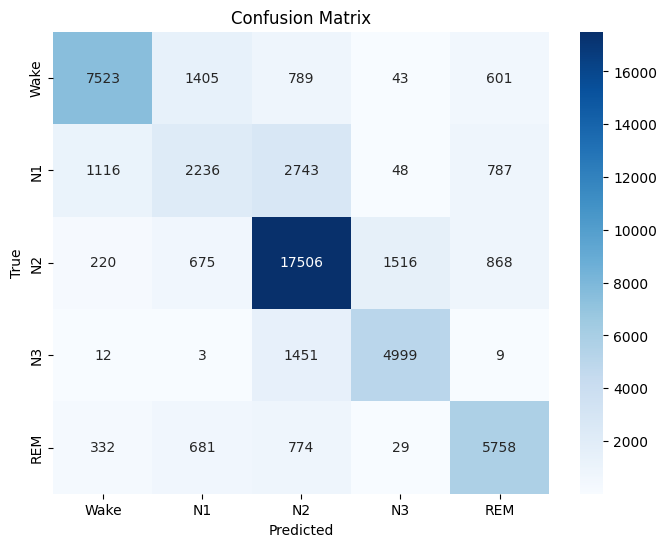

Cohen's Kappa: 0.6324123708379712


In [ ]:
lgb = lgb.LGBMClassifier(
    n_estimators=400,
    learning_rate=0.08,
    max_depth=10,
    num_leaves=125,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

y_pred_lgb = utils.train_model(lgb, X_train, y_train, X_val)

df_eval = utils.create_evaluation_table(y_val, y_pred_lgb,df_val)

utils.evaluate_model(df_eval['Label'], df_eval['Pred_Smooth'])

## LightGBM + Class weights

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.890149 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 61200
[LightGBM] [Info] Number of data points in the train set: 228213, number of used features: 240
[LightGBM] [Info] Start training from score -1.609488
[LightGBM] [Info] Start training from score -1.609459
[LightGBM] [Info] Start training from score -1.609367
[LightGBM] [Info] Start training from score -1.609429
[LightGBM] [Info] Start training from score -1.609447
Train time: 1073.23 seconds

Accuracy 0.7451

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.83      0.79      0.81     10361
          N1       0.45      0.41      0.43      6930
          N2       0.80      0.80      0.80     20785
          N3       0.72      0.84      0.78      6474
         REM       0.76      0.76      0.76      7574

    accuracy                        

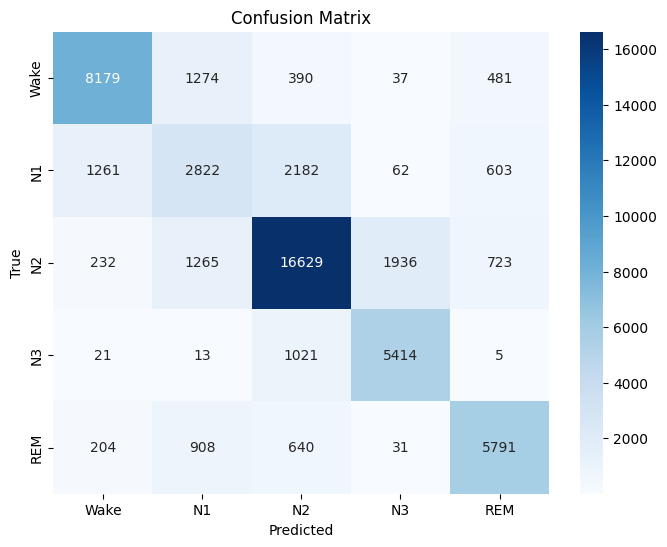

Cohen's Kappa: 0.658983136414349


In [ ]:
lgb = lgb.LGBMClassifier(
    n_estimators=400,
    learning_rate=0.08,
    max_depth=10,
    num_leaves=125,
    random_state=42,
    n_jobs=-1
)

y_pred_lgb = utils.train_model(
    lgb,
    X_train,
    y_train,
    X_val,
    sample_weights_custom
)

df_eval = utils.create_evaluation_table(y_val, y_pred_lgb,df_val)

utils.evaluate_model(df_eval['Label'], df_eval['Pred_Smooth'])

## LightGBM + Calibration + Class weights

* best

/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Accuracy 0.7492

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.82      0.79      0.81     10361
          N1       0.46      0.37      0.41      6930
          N2       0.78      0.83      0.80     20785
          N3       0.75      0.81      0.78      6474
         REM       0.77      0.76      0.76      7574

    accuracy                           0.75     52124
   macro avg       0.72      0.71      0.71     52124
weighted avg       0.74      0.75      0.74     52124



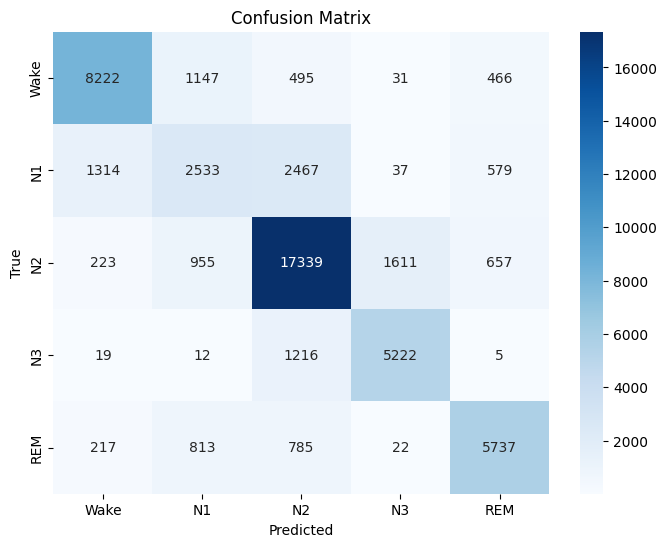

Cohen's Kappa: 0.6611678622669992


In [ ]:

calib_lgb = CalibratedClassifierCV(
        estimator=lgb.LGBMClassifier(
            n_estimators=400,
            learning_rate=0.08,
            max_depth=10,
            num_leaves=125,
            random_state=42,
            n_jobs=-1
        ),
        method='sigmoid',
        cv=5
)

calib_lgb.fit(X_val, y_val)

y_proba_calibrated = calib_lgb.predict_proba(X_val)
y_pred_calibrated = calib_lgb.predict(X_val)

df_eval = utils.create_evaluation_table(y_val, y_pred_calibrated,df_val)

utils.evaluate_model(df_eval['Label'], df_eval['Pred_Smooth'])

## XGBoost + Advance Temporal Context

Train time: 1181.70 seconds

Accuracy 0.7391

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.83      0.78      0.80     10361
          N1       0.43      0.43      0.43      6930
          N2       0.80      0.78      0.79     20785
          N3       0.71      0.85      0.77      6474
         REM       0.76      0.77      0.76      7574

    accuracy                           0.74     52124
   macro avg       0.71      0.72      0.71     52124
weighted avg       0.74      0.74      0.74     52124



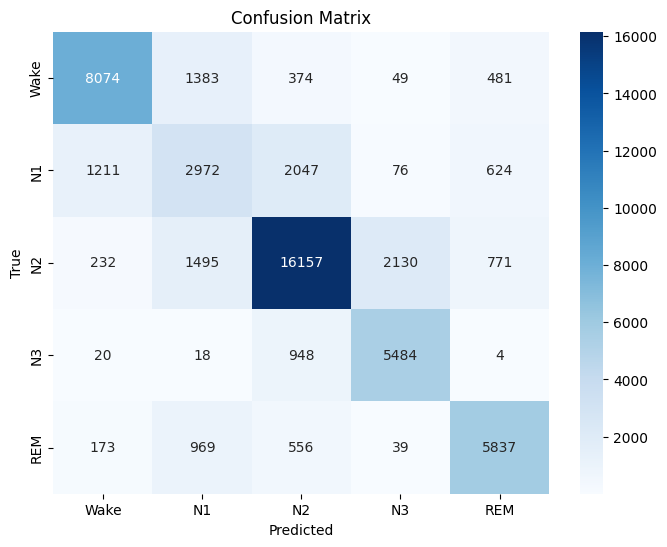

Cohen's Kappa: 0.6529690269193482


In [ ]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=5,
    eval_metric='mlogloss',
    random_state=42,
    n_estimators=400,
    learning_rate=0.08,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    enable_categorical=True,
    n_jobs=-1
)

y_pred_xgb = utils.train_model(
    xgb, X_train, y_train, X_val, sample_weights
    )

df_eval = utils.create_evaluation_table(y_val, y_pred_xgb,df_val)

utils.evaluate_model(df_eval['Label'], df_eval['Pred_Smooth'])

## XGBoost + Class Weights


Train time: 1180.80 seconds

Accuracy 0.7403

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.83      0.78      0.81     10361
          N1       0.44      0.43      0.43      6930
          N2       0.81      0.78      0.79     20785
          N3       0.71      0.85      0.77      6474
         REM       0.75      0.77      0.76      7574

    accuracy                           0.74     52124
   macro avg       0.71      0.72      0.71     52124
weighted avg       0.74      0.74      0.74     52124



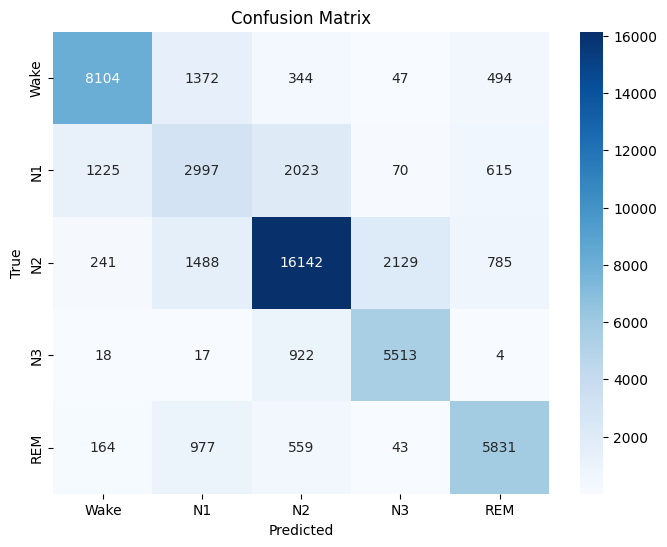

Cohen's Kappa: 0.6547682115864638


In [ ]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=5,
    eval_metric='mlogloss',
    random_state=42,
    n_estimators=400,
    learning_rate=0.08,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    enable_categorical=True,
    n_jobs=-1
)

y_pred_xgb = utils.train_model(
    xgb, X_train, y_train, X_val, sample_weights_custom
    )

df_eval = utils.create_evaluation_table(y_val, y_pred_xgb,df_val)

utils.evaluate_model(df_eval['Label'], df_eval['Pred_Smooth'])

## XGBoost + Calibration + Class Weights

* best XGBoost

Accuracy 0.7516

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.80      0.82      0.81     10361
          N1       0.51      0.24      0.32      6930
          N2       0.75      0.87      0.81     20785
          N3       0.78      0.78      0.78      6474
         REM       0.77      0.77      0.77      7574

    accuracy                           0.75     52124
   macro avg       0.72      0.70      0.70     52124
weighted avg       0.73      0.75      0.73     52124



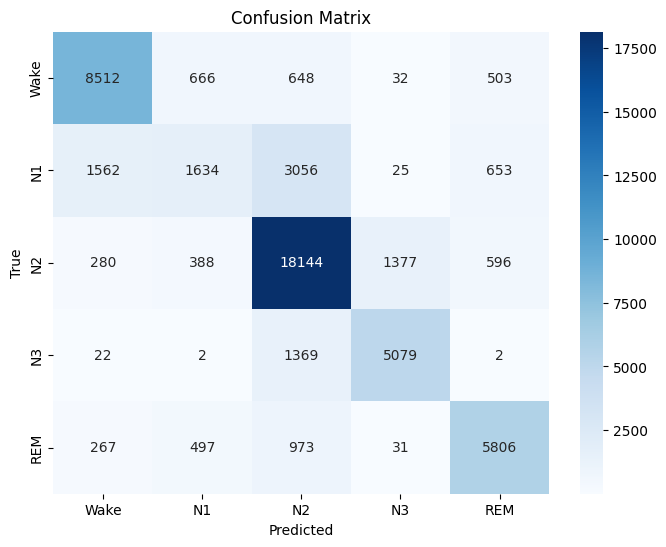

Cohen's Kappa: 0.6594821498021386


In [ ]:
xgb = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=5,
    eval_metric='mlogloss',
    random_state=42,
    n_estimators=400,
    learning_rate=0.08,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    enable_categorical=True,
    n_jobs=-1
)

calibrated_xgb = CalibratedClassifierCV(
    estimator=xgb,
    method='sigmoid',
    cv=5
)

calibrated_xgb.fit(X_train, y_train)

y_proba_calibrated = calibrated_xgb.predict_proba(X_val)
y_pred_calibrated = calibrated_xgb.predict(X_val)

df_eval = utils.create_evaluation_table(y_val, y_pred_calibrated,df_val)

utils.evaluate_model(df_eval['Label'], df_eval['Pred_Smooth'])

## Random Forest with Temporal Context

Train time: 787.68 seconds

Accuracy 0.7318

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.74      0.82      0.78     10361
          N1       0.49      0.22      0.30      6930
          N2       0.76      0.84      0.80     20785
          N3       0.78      0.77      0.78      6474
         REM       0.70      0.74      0.72      7574

    accuracy                           0.73     52124
   macro avg       0.69      0.68      0.67     52124
weighted avg       0.71      0.73      0.71     52124



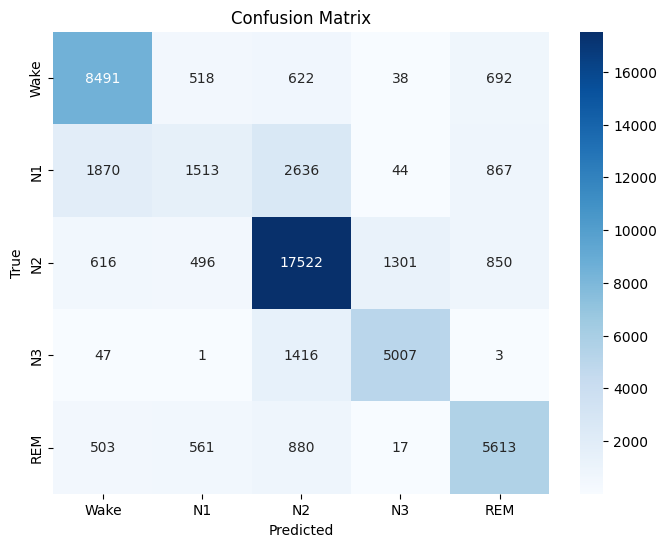

Cohen's Kappa: 0.6346418852626734


In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

y_rf_pred = utils.train_model(rf, X_train, y_train, X_val)

utils.evaluate_model(y_val, y_rf_pred)

## RF + Calibration

* best RF

Accuracy 0.7321

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.75      0.81      0.78     10361
          N1       0.48      0.23      0.31      6930
          N2       0.75      0.85      0.80     20785
          N3       0.80      0.75      0.77      6474
         REM       0.71      0.74      0.72      7574

    accuracy                           0.73     52124
   macro avg       0.70      0.68      0.68     52124
weighted avg       0.71      0.73      0.72     52124



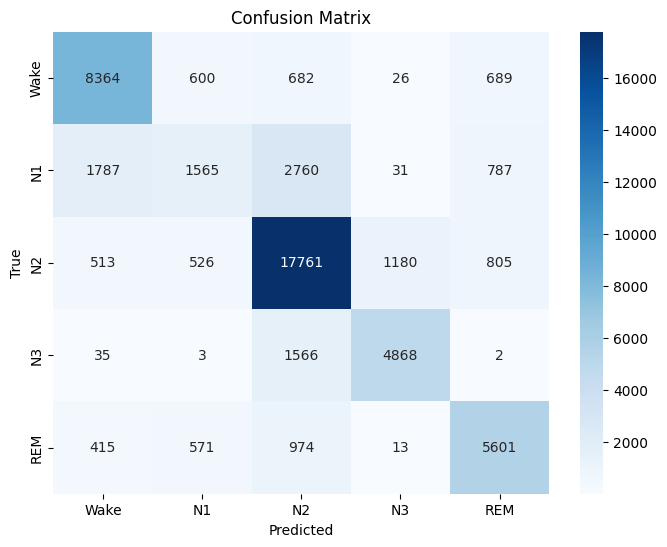

Cohen's Kappa: 0.6335363066809532


In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

calibrated_rf = CalibratedClassifierCV(
    estimator=rf,
    method='sigmoid',
    cv=5
)

calibrated_rf.fit(X_train, y_train)

y_proba_calibrated = calibrated_rf.predict_proba(X_val)
y_pred_calibrated = calibrated_rf.predict(X_val)

df_eval = utils.create_evaluation_table(y_val, y_pred_calibrated,df_val)

utils.evaluate_model(df_eval['Label'], df_eval['Pred_Smooth'])

## RF + Class Weights

Train time: 870.69 seconds

Accuracy 0.7293

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.73      0.81      0.77     10361
          N1       0.48      0.24      0.32      6930
          N2       0.76      0.83      0.79     20785
          N3       0.78      0.78      0.78      6474
         REM       0.69      0.75      0.72      7574

    accuracy                           0.73     52124
   macro avg       0.69      0.68      0.68     52124
weighted avg       0.71      0.73      0.71     52124



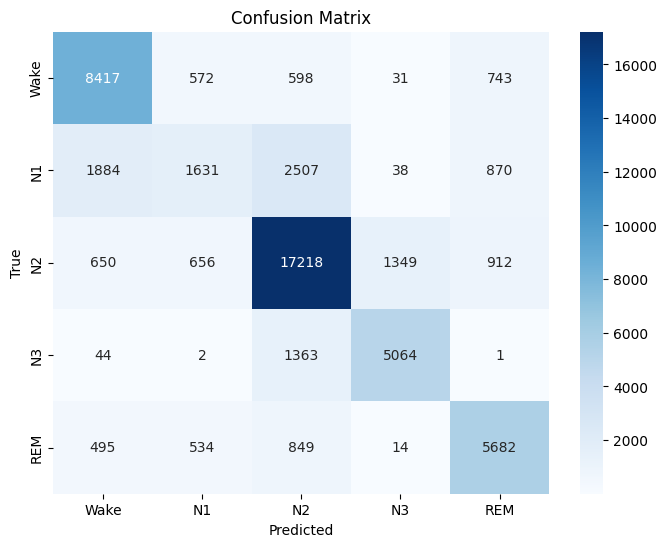

Cohen's Kappa: 0.6325297538009573


In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

y_rf_pred = utils.train_model(
    rf, X_train, y_train, X_val, sample_weights_custom)

utils.evaluate_model(y_val, y_rf_pred)